# 摩擦音モデル — Phase 1: 乱流音源の基礎

このノートブックでは、声道の狭窄部で発生する乱流が摩擦音の音源となる仕組みを数値的に確認し、
簡単なノイズフィルタリングモデルで /s/・/ʃ/・/f/ に似た音を合成する。

**合成パイプライン**
```
収縮パラメータ (Ac, Q)
   │
   ▼
レイノルズ数 Re = 2Q / (ν √(πAc))
   │
   ▼
ノイズ振幅  σ(Re) = k · max(0, Re − Re_crit)^α
   │
   ▼
白色ガウスノイズ × σ(Re)
   │
   ▼
前方腔フィルタ（高域通過 + 共鳴ピーク）
   │
   ▼
出力波形（WAV / Audio）
```

**参考文献**
- Shadle, C.H. (1985). *The acoustics of fricative consonants.* MIT RLE Tech. Report 506.
- McGowan, R.S. (1988). Tongue-tip trills and vocal-tract wall compliance. *JASA*, 83(1), 27–29.
- Stevens, K.N. (1998). *Acoustic Phonetics.* MIT Press. Chapter 7.

## 準備：ライブラリのインポート

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from IPython.display import Audio, display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#1e293b',
    'axes.facecolor':   '#0f172a',
    'axes.edgecolor':   '#475569',
    'axes.labelcolor':  '#cbd5e1',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'lines.linewidth':  1.8,
})

print('ライブラリ読み込み完了')

ライブラリ読み込み完了


---
## 1. 物理定数とレイノルズ数

### なぜレイノルズ数が重要か

レイノルズ数 Re は「慣性力 / 粘性力」の比であり、流れが層流（laminar）か乱流（turbulent）かを決定する。
管内流の場合、**Re ≳ 1800 で乱流遷移**が起きる。

声道の収縮部（断面積 $A_c$、容積速度 $Q$）に対して：

$$
v = \frac{Q}{A_c}, \quad
d_h = 2\sqrt{\frac{A_c}{\pi}}, \quad
\mathrm{Re} = \frac{v \, d_h}{\nu} = \frac{2Q}{\nu \sqrt{\pi A_c}}
$$

- $v$ : 収縮部での流速 [m/s]
- $d_h$ : 油圧直径（円断面を仮定）[m]
- $\nu = 1.5 \times 10^{-5}$ m²/s : 空気の動粘性係数
- $Q$ : 容積速度 [m³/s]（発話時の典型値 ≈ 100–300 cc/s）

In [2]:
# ── 物理定数 ─────────────────────────────────────
FS       = 44100          # サンプルレート [Hz]
C        = 343.0          # 音速 [m/s]
NU       = 1.5e-5         # 空気の動粘性係数 [m²/s]
RHO      = 1.2            # 空気密度 [kg/m³]
RE_CRIT  = 1800.0         # 乱流遷移の臨界レイノルズ数

def reynolds_number(Q_m3s: float, Ac_m2: float) -> float:
    """
    収縮部のレイノルズ数を計算する。

    Parameters
    ----------
    Q_m3s  : 容積速度 [m³/s]
    Ac_m2  : 収縮断面積 [m²]
    """
    v  = Q_m3s / Ac_m2
    dh = 2.0 * np.sqrt(Ac_m2 / np.pi)
    return v * dh / NU

# ── 動作確認 ─────────────────────────────────────
example_cases = [
    ('/s/  (Ac=0.15cm²)', 200e-6, 0.15e-4),
    ('/ʃ/  (Ac=0.20cm²)', 200e-6, 0.20e-4),
    ('/f/  (Ac=0.30cm²)', 200e-6, 0.30e-4),
    ('/a/  (Ac=3.00cm²)', 200e-6, 3.00e-4),
]
print(f"{'音素':<20}  {'Re':>8}  {'状態'}")
print('-' * 40)
for label, Q, Ac in example_cases:
    Re = reynolds_number(Q, Ac)
    state = '乱流 ✓' if Re > RE_CRIT else '層流  '
    print(f"{label:<20}  {Re:>8.0f}  {state}")

音素                          Re  状態
----------------------------------------
/s/  (Ac=0.15cm²)         3885  乱流 ✓
/ʃ/  (Ac=0.20cm²)         3364  乱流 ✓
/f/  (Ac=0.30cm²)         2747  乱流 ✓
/a/  (Ac=3.00cm²)          869  層流  


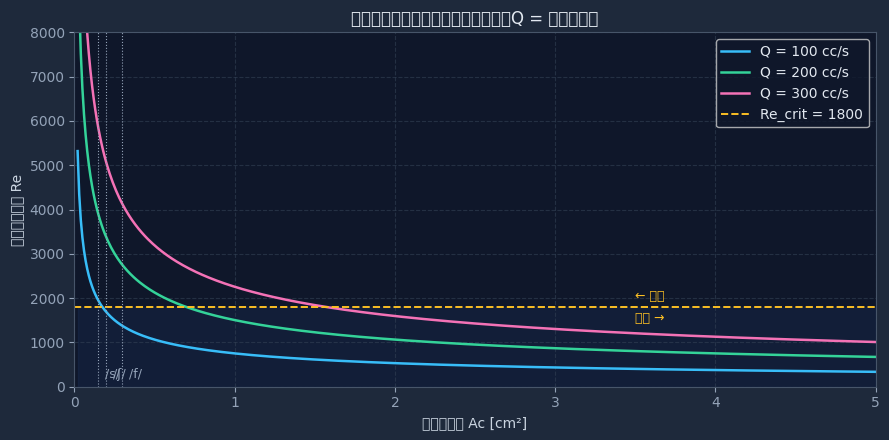

In [3]:
# ── Re vs 収縮面積 のグラフ ────────────────────────
Ac_range = np.linspace(0.02e-4, 5.0e-4, 500)   # 0.02〜5.00 cm²
Q_values = [100e-6, 200e-6, 300e-6]             # 100/200/300 cc/s
colors   = ['#38bdf8', '#34d399', '#f472b6']
labels   = ['Q = 100 cc/s', 'Q = 200 cc/s', 'Q = 300 cc/s']

fig, ax = plt.subplots(figsize=(9, 4.5))

for Q, col, lbl in zip(Q_values, colors, labels):
    Re_vals = reynolds_number(Q, Ac_range)
    ax.plot(Ac_range * 1e4, Re_vals, color=col, label=lbl)

# 臨界 Re の水平線
ax.axhline(RE_CRIT, color='#fbbf24', linewidth=1.4, linestyle='--', label=f'Re_crit = {RE_CRIT:.0f}')
ax.fill_between(Ac_range * 1e4, RE_CRIT, 0, alpha=0.07, color='#3b82f6')

# 代表的な摩擦音の位置に縦線
for ac_cm2, phoneme in [(0.15, '/s/'), (0.20, '/ʃ/'), (0.30, '/f/')]:
    ax.axvline(ac_cm2, color='#94a3b8', linewidth=0.8, linestyle=':')
    ax.text(ac_cm2 + 0.04, 200, phoneme, color='#94a3b8', fontsize=9)

ax.set_xlabel('収縮断面積 Ac [cm²]')
ax.set_ylabel('レイノルズ数 Re')
ax.set_title('収縮断面積とレイノルズ数の関係（Q = 容積速度）')
ax.set_xlim(0, 5)
ax.set_ylim(0, 8000)
ax.legend(loc='upper right')
ax.grid(True)
ax.text(3.5, RE_CRIT + 150, '← 乱流', color='#fbbf24', fontsize=9)
ax.text(3.5, RE_CRIT - 350, '層流 →', color='#fbbf24', fontsize=9)
plt.tight_layout()
plt.show()

---
## 2. 乱流ノイズ振幅モデル σ(Re)

Shadle (1985) の簡略モデルでは、乱流音源の振幅は臨界 Re を超えた分に比例する：

$$
\sigma(\mathrm{Re}) = k \cdot \max\bigl(0,\; \mathrm{Re} - \mathrm{Re}_{\mathrm{crit}}\bigr)^{\alpha}
$$

- $\alpha \approx 1.0$〜$1.5$ : 成長の急峻さ（本ノートブックでは $\alpha = 1.0$）
- $k$ : 正規化定数（後段で音量スケールに合わせる）

Re が大きいほどノイズが強く、Re < Re_crit では完全に無音になる。

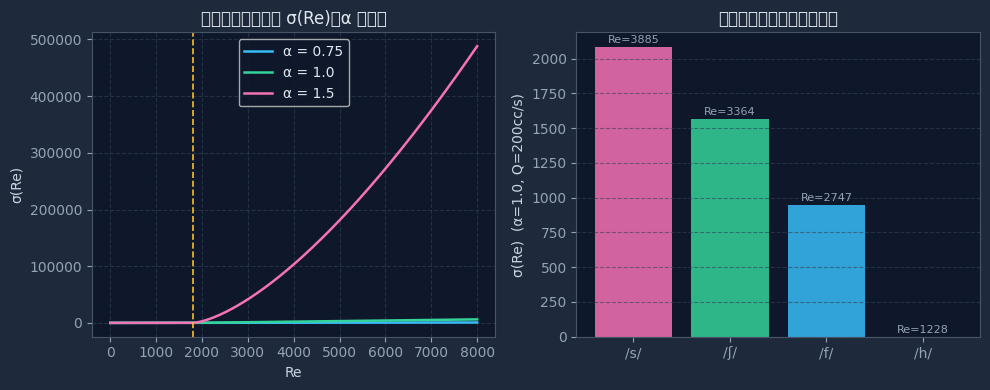


各音素の詳細:
音素        Ac [cm²]        Re     σ(Re)
----------------------------------------
/s/           0.15      3885    2084.6
/ʃ/           0.20      3364    1564.2
/f/           0.30      2747     946.8
/h/           1.50      1228       0.0


In [4]:
def noise_amplitude(Re: float | np.ndarray, alpha: float = 1.0) -> float | np.ndarray:
    """乱流ノイズの相対振幅 σ(Re)。最大値が 1.0 になるよう正規化しない（後段で行う）。"""
    return np.maximum(0.0, Re - RE_CRIT) ** alpha

# ── σ(Re) のグラフ ───────────────────────────────
Re_range = np.linspace(0, 8000, 500)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# α比較
for alpha, col in [(0.75, '#38bdf8'), (1.0, '#34d399'), (1.5, '#f472b6')]:
    axes[0].plot(Re_range, noise_amplitude(Re_range, alpha), color=col, label=f'α = {alpha}')
axes[0].axvline(RE_CRIT, color='#fbbf24', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Re')
axes[0].set_ylabel('σ(Re)')
axes[0].set_title('ノイズ振幅モデル σ(Re)（α 比較）')
axes[0].legend()
axes[0].grid(True)

# 各摩擦音の Re と σ（Q=200cc/s, α=1.0）
phoneme_data = [
    ('/s/',  0.15e-4, '#f472b6'),
    ('/ʃ/',  0.20e-4, '#34d399'),
    ('/f/',  0.30e-4, '#38bdf8'),
    ('/h/',  1.50e-4, '#a78bfa'),
]
Q_demo = 200e-6
for phoneme, Ac, col in phoneme_data:
    Re = reynolds_number(Q_demo, Ac)
    sig = noise_amplitude(Re)
    axes[1].bar(phoneme, sig, color=col, alpha=0.85)
    axes[1].text(phoneme, sig + 30, f'Re={Re:.0f}', ha='center', fontsize=8, color='#94a3b8')
axes[1].set_ylabel('σ(Re)  (α=1.0, Q=200cc/s)')
axes[1].set_title('各摩擦音の相対ノイズ強度')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

print("\n各音素の詳細:")
print(f"{'音素':<6}  {'Ac [cm²]':>10}  {'Re':>8}  {'σ(Re)':>8}")
print('-' * 40)
for phoneme, Ac, _ in phoneme_data:
    Re = reynolds_number(Q_demo, Ac)
    print(f"{phoneme:<6}  {Ac*1e4:>10.2f}  {Re:>8.0f}  {noise_amplitude(Re):>8.1f}")

---
## 3. 前方腔フィルタモデル（下流声道共鳴）

摩擦音のスペクトル形状を決定するのは、**収縮部より前方（口側）の腔**の共鳴特性である。

この前方腔を「片端閉・片端開の気柱」として近似すると、共鳴周波数は：

$$
f_n = \frac{(2n-1) \cdot c}{4 L_{\text{front}}}, \quad n = 1, 2, 3, \ldots
$$

| 音素 | 収縮部位 | 前方腔長 $L$ | 第1共鳴 $f_1$ | 特徴 |
|------|----------|-------------|-------------|------|
| /s/  | 歯茎（前部） | ≈ 2 cm | ≈ 4300 Hz | 高い「シー」 |
| /ʃ/  | 後部歯茎 | ≈ 3.5 cm | ≈ 2450 Hz | 低い「シャー」 |
| /f/  | 唇歯（口唇近傍） | ≈ 5 cm | ≈ 1720 Hz | 広帯域・拡散的 |

フィルタ実装：**高域通過フィルタ（低域除去）** + **バンドパス（前方腔共鳴ピーク）**

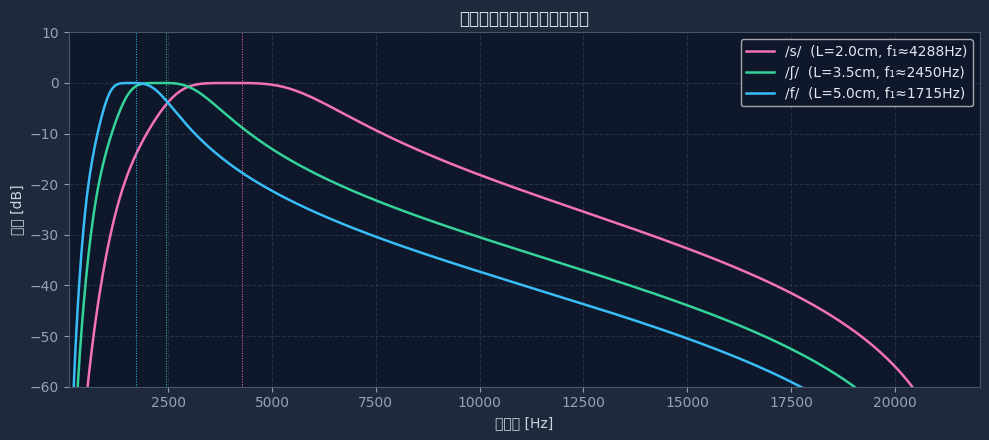

In [5]:
def front_cavity_filter(L_front_m: float, fs: int = FS):
    """
    前方腔フィルタを SOS（Second-Order Sections）形式で返す。
    高域通過 3次バターワース + 共鳴帯域フィルタ 2次の直列。

    Parameters
    ----------
    L_front_m : 前方腔長 [m]
    fs        : サンプルレート [Hz]
    """
    nyq = fs / 2.0

    # 第1共鳴周波数
    f1 = C / (4 * L_front_m)

    # 高域通過：f1/3 をカットオフに設定（低域を除去）
    hp_cut = max(200.0, f1 / 3.0)
    sos_hp = signal.butter(3, hp_cut / nyq, btype='high', output='sos')

    # 共鳴帯域フィルタ：f1 ± 40% をバンドパス
    bw_frac = 0.40
    low  = max(300.0,       f1 * (1 - bw_frac))
    high = min(nyq - 200.0, f1 * (1 + bw_frac))
    sos_bp = signal.butter(2, [low / nyq, high / nyq], btype='band', output='sos')

    return sos_hp, sos_bp, f1


# ── フィルタ周波数特性の可視化 ─────────────────────
fricative_presets = {
    '/s/':  {'Ac_cm2': 0.15, 'L_front_cm': 2.0,  'color': '#f472b6'},
    '/ʃ/':  {'Ac_cm2': 0.20, 'L_front_cm': 3.5,  'color': '#34d399'},
    '/f/':  {'Ac_cm2': 0.30, 'L_front_cm': 5.0,  'color': '#38bdf8'},
}

fig, ax = plt.subplots(figsize=(10, 4.5))

for phoneme, params in fricative_presets.items():
    L = params['L_front_cm'] * 1e-2
    sos_hp, sos_bp, f1 = front_cavity_filter(L, FS)

    # 周波数応答（HP + BP の合成）
    freqs = np.linspace(100, FS / 2, 4096)
    _, H_hp = signal.sosfreqz(sos_hp, worN=freqs, fs=FS)
    _, H_bp = signal.sosfreqz(sos_bp, worN=freqs, fs=FS)
    H_total = np.abs(H_hp) * np.abs(H_bp)
    H_db = 20 * np.log10(H_total + 1e-10)

    ax.plot(freqs, H_db, color=params['color'],
            label=f"{phoneme}  (L={params['L_front_cm']}cm, f₁≈{f1:.0f}Hz)")
    ax.axvline(f1, color=params['color'], linewidth=0.7, linestyle=':')

ax.set_xlabel('周波数 [Hz]')
ax.set_ylabel('振幅 [dB]')
ax.set_title('前方腔フィルタの周波数特性')
ax.set_xlim(100, FS / 2)
ax.set_ylim(-60, 10)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---
## 4. 摩擦音の合成と試聴

以下の手順で波形を生成する：

1. 白色ガウスノイズを生成
2. σ(Re) で振幅スケール
3. 前方腔フィルタを適用
4. フェードイン / フェードアウト（20ms）でクリック防止
5. 正規化

In [6]:
def generate_fricative(
    Ac_cm2:      float = 0.15,
    L_front_cm:  float = 2.0,
    Q_ccps:      float = 200.0,
    duration:    float = 1.5,
    gain:        float = 0.6,
    fs:          int   = FS,
    seed:        int | None = 42,
) -> tuple[np.ndarray, dict]:
    """
    摩擦音のモノラル波形を生成して返す。

    Returns
    -------
    wav    : float32 配列（−1〜1）
    info   : パラメータ情報の辞書
    """
    rng = np.random.default_rng(seed)
    N   = int(duration * fs)

    # 単位変換
    Q  = Q_ccps * 1e-6    # m³/s
    Ac = Ac_cm2  * 1e-4   # m²
    L  = L_front_cm * 1e-2 # m

    # レイノルズ数 & ノイズ振幅
    Re  = reynolds_number(Q, Ac)
    amp = noise_amplitude(Re)

    # 白色ノイズ
    noise = rng.standard_normal(N).astype(np.float64)

    # 前方腔フィルタ適用
    sos_hp, sos_bp, f1 = front_cavity_filter(L, fs)
    noise = signal.sosfilt(sos_hp, noise)
    noise = signal.sosfilt(sos_bp, noise)

    # フェードイン / フェードアウト（20ms）
    fade = int(0.02 * fs)
    env = np.ones(N)
    env[:fade]  = np.linspace(0.0, 1.0, fade)
    env[-fade:] = np.linspace(1.0, 0.0, fade)
    noise *= env

    # 正規化 & 振幅スケール
    REF_AMP = 5000.0   # σ(Re) の参照値（正規化用）
    peak = np.max(np.abs(noise))
    if peak > 1e-10:
        noise = noise / peak * gain * min(1.0, amp / REF_AMP)

    wav = noise.astype(np.float32)
    info = {'Re': Re, 'sigma': amp, 'f1': f1,
            'Ac_cm2': Ac_cm2, 'L_front_cm': L_front_cm, 'Q_ccps': Q_ccps}
    return wav, info

In [7]:
# ── /s/ 歯茎摩擦音 ───────────────────────────────
wav_s, info_s = generate_fricative(Ac_cm2=0.15, L_front_cm=2.0)
print(f"/s/  Re={info_s['Re']:.0f}  σ={info_s['sigma']:.0f}  前方腔共鳴={info_s['f1']:.0f} Hz")
display(Audio(wav_s, rate=FS))

/s/  Re=3885  σ=2085  前方腔共鳴=4288 Hz


In [8]:
# ── /ʃ/ 後部歯茎摩擦音 ───────────────────────────
wav_sh, info_sh = generate_fricative(Ac_cm2=0.20, L_front_cm=3.5)
print(f"/ʃ/  Re={info_sh['Re']:.0f}  σ={info_sh['sigma']:.0f}  前方腔共鳴={info_sh['f1']:.0f} Hz")
display(Audio(wav_sh, rate=FS))

/ʃ/  Re=3364  σ=1564  前方腔共鳴=2450 Hz


In [9]:
# ── /f/ 唇歯摩擦音 ───────────────────────────────
wav_f, info_f = generate_fricative(Ac_cm2=0.30, L_front_cm=5.0)
print(f"/f/  Re={info_f['Re']:.0f}  σ={info_f['sigma']:.0f}  前方腔共鳴={info_f['f1']:.0f} Hz")
display(Audio(wav_f, rate=FS))

/f/  Re=2747  σ=947  前方腔共鳴=1715 Hz


---
## 5. スペクトログラムと波形の比較

3 つの摩擦音を並べて視覚的に比較する。
- 前方腔が短い /s/ ほどエネルギーが高域に集中するはず。
- 振幅（Re に比例）は /s/ > /ʃ/ > /f/ の順に小さくなるはず。

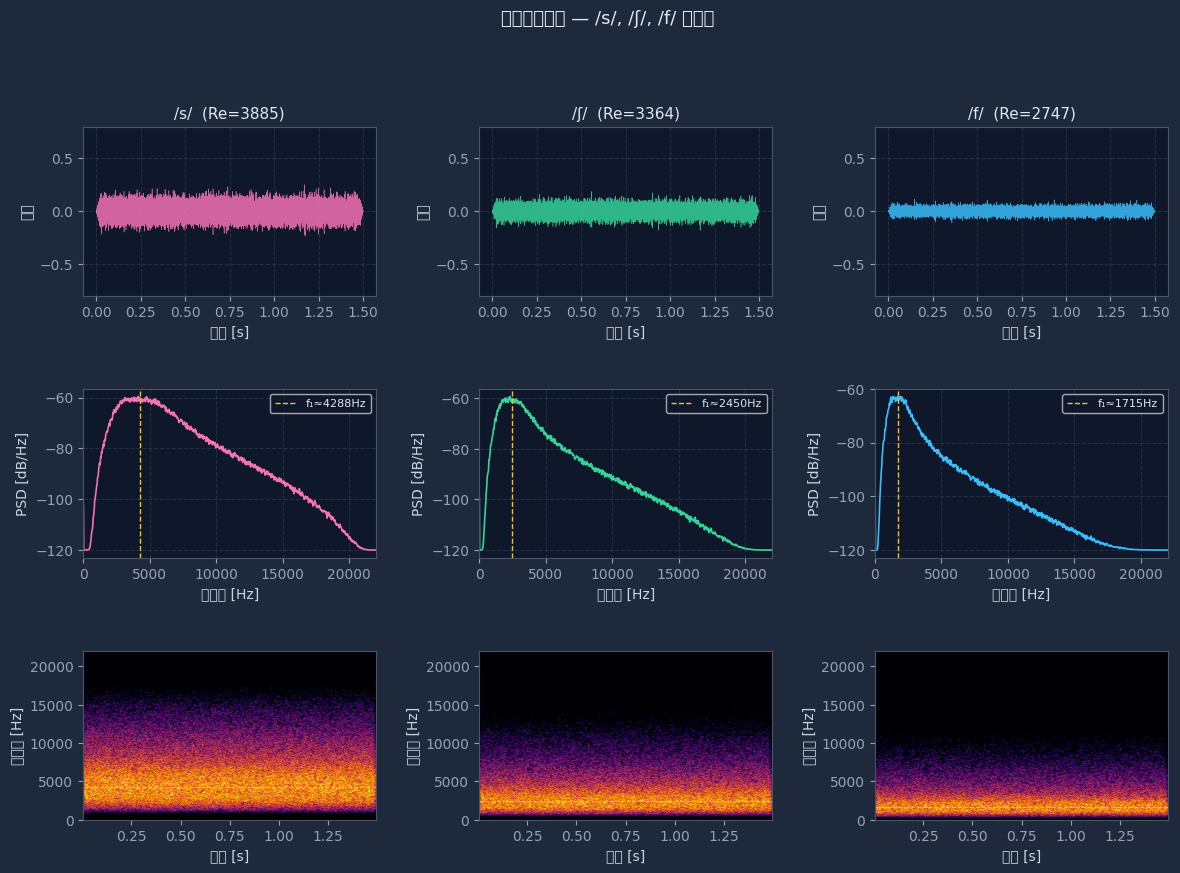

画像を data/processed/analysis/frication_comparison.png に保存しました


In [10]:
samples   = [wav_s,       wav_sh,      wav_f      ]
phonemes  = ['/s/',       '/ʃ/',       '/f/'      ]
colors    = ['#f472b6',   '#34d399',   '#38bdf8'  ]
infos     = [info_s,      info_sh,     info_f     ]

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

for col_idx, (wav, phoneme, col, info) in enumerate(zip(samples, phonemes, colors, infos)):
    t = np.arange(len(wav)) / FS

    # ── 波形 ───────────────────────────
    ax_wave = fig.add_subplot(gs[0, col_idx])
    ax_wave.plot(t, wav, color=col, linewidth=0.4, alpha=0.85)
    ax_wave.set_title(f'{phoneme}  (Re={info["Re"]:.0f})', fontsize=11)
    ax_wave.set_xlabel('時間 [s]')
    ax_wave.set_ylabel('振幅')
    ax_wave.set_ylim(-0.8, 0.8)
    ax_wave.grid(True)

    # ── スペクトル（平均パワー）────────
    ax_spec = fig.add_subplot(gs[1, col_idx])
    freqs_spec, psd = signal.welch(wav, fs=FS, nperseg=2048)
    psd_db = 10 * np.log10(psd + 1e-12)
    ax_spec.plot(freqs_spec, psd_db, color=col, linewidth=1.2)
    ax_spec.axvline(info['f1'], color='#fbbf24', linewidth=1.0, linestyle='--',
                    label=f'f₁≈{info["f1"]:.0f}Hz')
    ax_spec.set_xlabel('周波数 [Hz]')
    ax_spec.set_ylabel('PSD [dB/Hz]')
    ax_spec.set_xlim(0, FS / 2)
    ax_spec.legend(fontsize=8)
    ax_spec.grid(True)

    # ── スペクトログラム ────────────────
    ax_sg = fig.add_subplot(gs[2, col_idx])
    f_sg, t_sg, Sxx = signal.spectrogram(wav, fs=FS, nperseg=512, noverlap=480)
    Sxx_db = 10 * np.log10(Sxx + 1e-12)
    ax_sg.pcolormesh(t_sg, f_sg, Sxx_db, shading='gouraud', cmap='inferno',
                     vmin=Sxx_db.max() - 50, vmax=Sxx_db.max())
    ax_sg.axhline(info['f1'], color='#fbbf24', linewidth=0.8, linestyle='--')
    ax_sg.set_xlabel('時間 [s]')
    ax_sg.set_ylabel('周波数 [Hz]')
    ax_sg.set_ylim(0, FS / 2)

fig.suptitle('摩擦音モデル — /s/, /ʃ/, /f/ の比較', fontsize=13, y=1.01)
plt.savefig('../data/processed/analysis/frication_comparison.png',
            dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('画像を data/processed/analysis/frication_comparison.png に保存しました')

---
## 6. パラメータ感度の確認

収縮面積 $A_c$ を変化させたときに音がどう変わるかをスイープで確認する。  
面積が大きくなる（= Re が低下する）と摩擦音が弱くなり、ある閾値で消える様子を聴ける。

In [11]:
# Ac を 0.10 → 0.50 cm² にスイープ（/s/ 位置固定）
Ac_sweep   = [0.10, 0.15, 0.20, 0.30, 0.50]
print('Ac スイープ（前方腔長 2.0cm 固定）\n')
for Ac in Ac_sweep:
    wav, info = generate_fricative(Ac_cm2=Ac, L_front_cm=2.0, seed=0)
    Re = info['Re']
    state = '乱流' if Re > RE_CRIT else '層流（無音に近い）'
    print(f"Ac={Ac:.2f}cm²  Re={Re:.0f}  {state}")
    display(Audio(wav, rate=FS))

Ac スイープ（前方腔長 2.0cm 固定）

Ac=0.10cm²  Re=4758  乱流


Ac=0.15cm²  Re=3885  乱流


Ac=0.20cm²  Re=3364  乱流


Ac=0.30cm²  Re=2747  乱流


Ac=0.50cm²  Re=2128  乱流


---
## まとめと次のステップ

### Phase 1 で確認できたこと

| 項目 | 結果 |
|------|------|
| Re vs Ac | 収縮面積が小さいほど Re が大きく、乱流が起きやすい |
| σ(Re) モデル | 臨界 Re を超えた分だけノイズが増加（/s/ > /ʃ/ > /f/） |
| 前方腔フィルタ | 腔長が短いほど共鳴が高域にシフトし /s/ と /ʃ/ の違いが生まれる |
| スペクトル | /s/ は 4kHz 以上、/ʃ/ は 2–4kHz、/f/ はより拡散的 |

### Phase 2 に向けた課題

1. **後方腔（声門側）のフィルタも加える**  
   現状は前方腔のみ。声道全体の共鳴を加えるとより自然な音色になる。

2. **有声摩擦音（/v/, /z/）の合成**  
   LF モデル声帯音源（周期的）+ 摩擦ノイズ（確率的）を混合する。

3. **摩擦音→母音 の連続遷移（コアーティキュレーション）**  
   声道形状を時変させながら $A_c$ をなめらかに開くと /sa/ などが合成できる。

4. **第3プロトタイプ（波動管モデル）への統合**  
   各セクションの Re を計算し、最大 Re のセクションで摩擦ノイズを注入。  
   収縮が強い時だけ自動的に摩擦音源が立ち上がる。

5. **実録音との定量比較**  
   実際の /s/ WAV ファイルと Welch PSD を重ねて、前方腔長パラメータを調整する。